# Minimal Example

In [1]:
# %pip install matplotlib ipympl
import jax
jax.config.update("jax_enable_x64", True) # unfortunately we currently require double precision
import jax.numpy as jnp
import matplotlib.pyplot as plt
# %matplotlib widget
import numpy as np
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# jax.config.update('jax_platform_name', 'cpu')


In [2]:
## these are the main modules for background evolution and perturbation evolution
from discoeb.background import evolve_background
from discoeb.perturbations import evolve_perturbations, get_power, evolve_perturbations_batched

/home/raphael/venv/discodj_env/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [3]:
@jax.jit
def compute_matter_power( Omegam=0.3099, mnu=0.0):

  ## Set the Cosmological Parameters
  # insert parameters into a dictionary
  param = {}
  # OmegaDE is inferred since flatness is assumed currently
  param['Omegam']  = Omegam            # Total matter density parameter
  param['Omegab']  = 0.0488911        # Baryon density parameter
  param['w_DE_0']  = -0.99             # Dark energy equation of state parameter today
  param['w_DE_a']  = 0.0               # Dark energy equation of state parameter time derivative
  param['cs2_DE']  = 1.0               # Dark energy sound speed squared
  param['Omegak']  = 0.0
  param['A_s']     = 2.1064e-09        # Scalar amplitude of the primordial power spectrum
  param['n_s']     = 0.96822           # Scalar spectral index
  param['H0']      = 67.742            # Hubble constant today in units of 100 km/s/Mpc
  param['Tcmb']    = 2.7255            # CMB temperature today in K
  param['YHe']     = 0.248             # Helium mass fraction
  param['Neff']    = 2.046             # Effective number of ultrarelativistic neutrinos
                                       # -1 if massive neutrino present
  param['Nmnu']    = 1                 # Number of massive neutrinos (must be 1 currently)
  param['mnu']     = mnu              # Sum of neutrino masses in eV 
  param['k_p']     = 0.05              # Pivot scale in 1/Mpc

  # modes to sample
  nmodes = 512                         # number of modes to sample
  kmin   = 1e-4                        # minimum k in 1/Mpc
  kmax   = 10                          # maximum k in 1/Mpc
  aexp   = 1.0                         # scale factor at which to evaluate the power spectrum
  
  ## Compute Background+thermal evolution
  param = evolve_background(param=param, thermo_module='RECFAST')

  # compute perturbation evolution
  aexp_out = jnp.array([aexp])
  # jax.profiler.start_trace("/tmp/tensorboard")
  y, kmodes, param = evolve_perturbations( param=param, kmin=kmin, kmax=kmax, num_k=nmodes, aexp_out=aexp_out, 
                                  # lmaxg = 31, lmaxgp = 31, lmaxr = 31, lmaxnu = 31, nqmax = 5, # from compare_class
                                  rtol=1e-3, atol=1e-3 , 
                                  )
  # jax.profiler.stop_trace()
  # turn perturbations into power spectra
  Pkm = get_power( k=kmodes, y=y[:,0,:], idx=6, param=param )

  return Pkm, kmodes

## Compute and plot the matter power spectrum

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2445080/3436181176.py:21: SyntaxWarning: invalid escape sequence '\s'
  plt.semilogx(kmodes,Pkm_nu/Pkm, label='$\sum m_i = '+str(sum_masses)+'$eV')


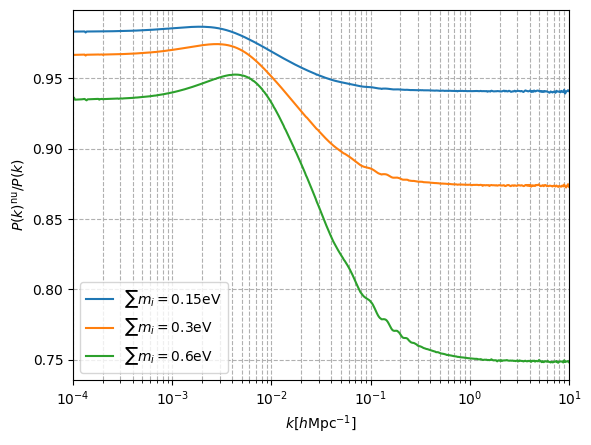

In [4]:
# might take ~ a minute to compile on first run, ~3s on rerun (RTX3090), 
# increase accuracy (rtol,atol) to reduce noise on derivatives
Omegam_fid = 0.3099

results_disco = []

h=0.67742

Pkm, kmodes = compute_matter_power( Omegam_fid,0 )

for sum_masses in [0.15, 0.3, 0.6]:
    Pkm_nu, kmodes_nu = compute_matter_power( Omegam_fid,sum_masses )

    results_disco.append({
        "k": kmodes,
        "ratio": Pkm_nu / Pkm,
        "mass": sum_masses,
        "method": "DISCOEB"
    })

    plt.semilogx(kmodes,Pkm_nu/Pkm, label='$\sum m_i = '+str(sum_masses)+'$eV')
plt.xlim(kmodes[0],kmodes[-1])
plt.xlabel(r'$k [h \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P(k)^\mathrm{nu}/P(k)$')  
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=10)

np.save("discoeb_results.npy", results_disco)